In [48]:
import numpy as np
import gudhi as gd
import pandas as pd
from sklearn import manifold
from pylab import *
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

In [71]:
tore = gd.read_points_from_off_file(off_file='data/points/tore3D_300.off')
tore2 = gd.read_points_from_off_file(off_file='data/points/human.off')

ac = gd.AlphaComplex(points=tore)
st = ac.create_simplex_tree()
ac2 =gd.AlphaComplex(points=tore2)
st2 =ac2.create_simplex_tree()

barcodes_a= st.persistence()
barcodes_b= st2.persistence()


In [72]:
I0=st.persistence_intervals_in_dimension(1)
I1=st2.persistence_intervals_in_dimension(1)
print(st.persistence_intervals_in_dimension(1))
print(st2.persistence_intervals_in_dimension(1))


[[0.00170246 0.00209885]
 [0.00573909 0.00573941]
 [0.00607073 0.00607081]
 [0.00848335 0.00849916]
 [0.00875832 0.00936752]
 [0.01129467 0.01290038]
 [0.01156367 0.0139935 ]
 [0.0135853  0.01420539]
 [0.01496941 0.01497494]
 [0.01539429 0.01540599]
 [0.01377374 0.01557524]
 [0.01527838 0.01558308]
 [0.01591976 0.01596034]
 [0.01690497 0.01750816]
 [0.01819037 0.01995146]
 [0.02160406 0.02262608]
 [0.02283536 0.02285497]
 [0.0227448  0.02307418]
 [0.02194741 0.02398321]
 [0.02477875 0.02484763]
 [0.02156851 0.02537445]
 [0.02580669 0.02637834]
 [0.0270028  0.02744902]
 [0.0279399  0.02805572]
 [0.02796272 0.02893891]
 [0.02912517 0.02928813]
 [0.02504829 0.02958085]
 [0.02988344 0.03015144]
 [0.02502288 0.0314705 ]
 [0.03215013 0.03217787]
 [0.0327273  0.03275824]
 [0.03302009 0.03520033]
 [0.03225415 0.03587881]
 [0.0354947  0.0362492 ]
 [0.03704608 0.03711908]
 [0.03371404 0.0376744 ]
 [0.03415309 0.03869508]
 [0.04012162 0.04014403]
 [0.04035362 0.04049156]
 [0.03775163 0.04066025]


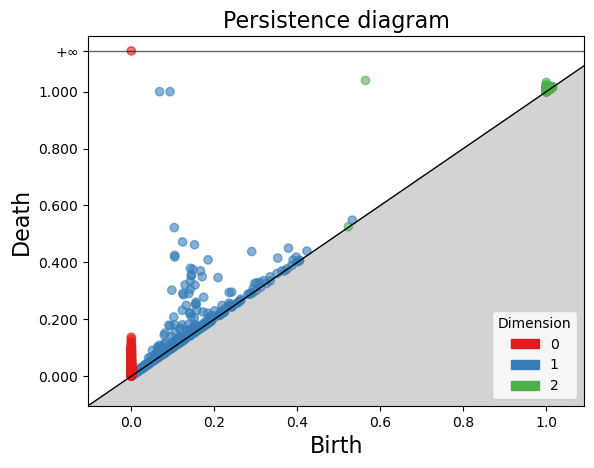

In [73]:
gd.plot_persistence_diagram(barcodes_a);

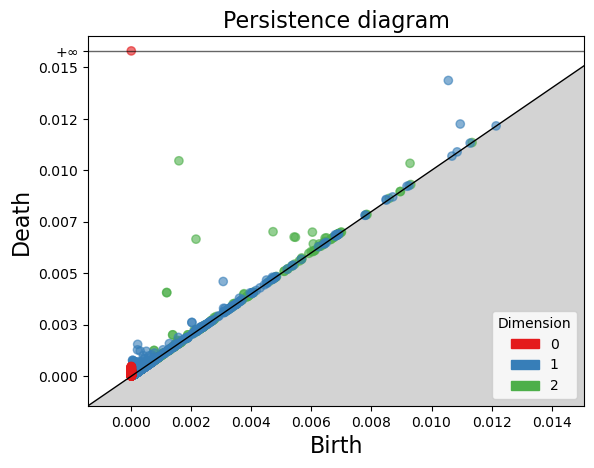

In [74]:
gd.plot_persistence_diagram(barcodes_b);

In [77]:
gd.bottleneck_distance(I0, I1)

#3rd term approximated error
gd.bottleneck_distance(I0, I1, 0.001)

0.4651868359792254

Visualization of graphs and persistence

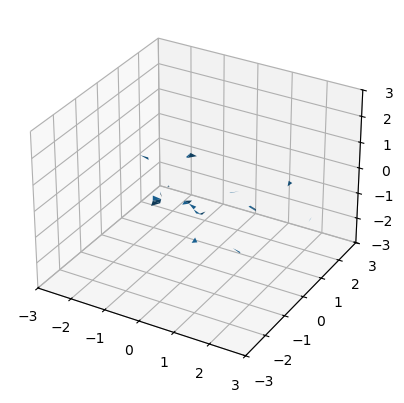

In [84]:
epsilon=0.02

points = np.array([ac.get_point(i) for i in range(st.num_vertices())])
triangles = np.array([s[0] for s in st.get_skeleton(2) if len(s[0]) == 3 and s[1] <= epsilon])


fig = plt.figure()
ax = fig.add_subplot(projection='3d')
l = ax.plot_trisurf(points[:, 0], points[:, 1], points[:, 2], triangles = triangles)
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_zlim(-3, 3)

plt.show()

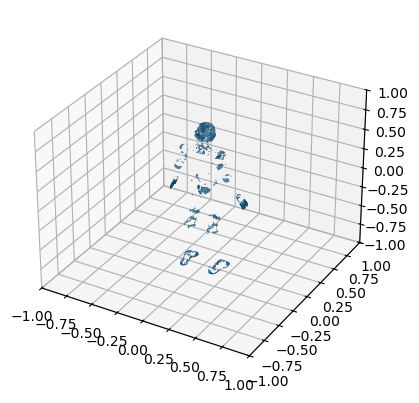

In [83]:
epsilon=0.0001

points = np.array([ac2.get_point(i) for i in range(st2.num_vertices())])
triangles = np.array([s[0] for s in st2.get_skeleton(2) if len(s[0]) == 3 and s[1] <= epsilon])


fig = plt.figure()
ax = fig.add_subplot(projection='3d')
l = ax.plot_trisurf(points[:, 0], points[:, 1], points[:, 2], triangles = triangles)
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_zlim(-1, 1)

plt.show()